# Pandas Revision Notebook

A structured, bug-fixed, and extended revision notebook covering core-to-intermediate
**pandas** concepts for data analysis interviews and day-to-day EDA work.

**How to use:** run the cells top to bottom. All sample data lives in the `data/`
folder next to this notebook, so it runs anywhere (no Google Colab paths needed).

Sections:
1. NumPy & Series basics
2. DataFrame basics & inspection
3. Selecting data: `.loc`, `.iloc`, `.at`, `.iat`
4. Sorting & iterating
5. Filtering data (boolean, string ops, regex, `.query`)
6. Adding / removing / transforming columns
7. Datetime operations
8. Custom logic with `.apply()` and lambdas
9. Merging & concatenating data
10. Handling missing values
11. Aggregating data: `value_counts`, `groupby`, `agg`, pivot tables
12. Duplicates & replacing values
13. Window functions: `rolling`, `expanding`, `shift`, `diff`
14. Method chaining with `.pipe()`
15. Performance notes (`.iterrows()` vs vectorization, `category` dtype)
16. Quick plotting
17. Saving your work


In [1]:
# Core imports used throughout the notebook
import pandas as pd
import numpy as np

## 1. NumPy & Series Basics

Create a plain NumPy array (not pandas yet, just for comparison).

In [2]:
a = np.array([10, 20, 30, 40, 50])
a

array([10, 20, 30, 40, 50])

A `Series` is a 1-D labeled array — think of it as a single column.

In [3]:
pd.Series([10, 20, 30, 40], index=[7, 8, 9, 10])

7     10
8     20
9     30
10    40
dtype: int64

Series can have descriptive string labels and a name (like a named column).

In [4]:
pd.Series([10, 20, 30, 40], index=['maths', 'science', 'english', 'social'], name='marks')

maths      10
science    20
english    30
social     40
Name: marks, dtype: int64

Series built directly from a NumPy range, with a custom index.

In [5]:
pd.Series(np.arange(5), index=np.arange(6, 11))

6     0
7     1
8     2
9     3
10    4
dtype: int64

A dict becomes a Series automatically: dict keys -> index, values -> data.

In [6]:
pd.Series({'a': 10, 'b': 20})

a    10
b    20
dtype: int64

Random integer Series, useful for quick experiments.

In [7]:
nums = pd.Series(np.random.randint(1, 100, 20))
nums

0      4
1     76
2     98
3     66
4     86
5     65
6     26
7     18
8     81
9     17
10    66
11    99
12    49
13    27
14    46
15    28
16    75
17    46
18    18
19    91
dtype: int64

Slice a Series by position, just like a Python list.

In [8]:
nums[11:15]

11    99
12    49
13    27
14    46
dtype: int64

## 2. DataFrame Basics & Inspection

Load a CSV into a DataFrame. Path is relative to this notebook's `data/` folder.

In [9]:
df = pd.read_csv('data/pokemon_data.csv')
df

,Name,Type1,Type2,HP,Attack,Defense,SpAtk,SpDef,Speed,Generation,Legendary
0,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,Charmander,Fire,NaN,39,52,43,60,50,65,1,False
4,Charmeleon,Fire,NaN,58,64,58,80,65,80,1,False
5,Charizard,Fire,Flying,78,84,78,109,85,100,1,False
6,Squirtle,Water,NaN,44,48,65,50,64,43,1,False
7,Wartortle,Water,NaN,59,63,80,65,80,58,1,False
8,Blastoise,Water,NaN,79,83,100,85,105,78,1,False
9,Pikachu,Electric,NaN,35,55,40,50,50,90,1,False


`.head(n)` shows the first n rows — always check this after loading data.

In [10]:
df.head(5)

,Name,Type1,Type2,HP,Attack,Defense,SpAtk,SpDef,Speed,Generation,Legendary
0,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,Charmander,Fire,NaN,39,52,43,60,50,65,1,False
4,Charmeleon,Fire,NaN,58,64,58,80,65,80,1,False


`.tail(n)` shows the last n rows.

In [11]:
df.tail(5)

,Name,Type1,Type2,HP,Attack,Defense,SpAtk,SpDef,Speed,Generation,Legendary
10,Raichu,Electric,NaN,60,90,55,90,80,110,1,False
11,Jigglypuff,Normal,Fairy,115,45,20,45,25,20,1,False
12,Zubat,Poison,Flying,40,45,35,30,40,55,1,False
13,Mewtwo,Psychic,NaN,106,110,90,154,90,130,1,True
14,Mew,Psychic,NaN,100,100,100,100,100,100,1,True


`.sample(n)` gives a random n-row snapshot, good for spotting data issues.

In [12]:
df.sample(5)

,Name,Type1,Type2,HP,Attack,Defense,SpAtk,SpDef,Speed,Generation,Legendary
7,Wartortle,Water,NaN,59,63,80,65,80,58,1,False
13,Mewtwo,Psychic,NaN,106,110,90,154,90,130,1,True
2,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
10,Raichu,Electric,NaN,60,90,55,90,80,110,1,False
14,Mew,Psychic,NaN,100,100,100,100,100,100,1,True


`.info()` shows dtypes, non-null counts, and memory usage in one shot.

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Name        15 non-null     str  
 1   Type1       15 non-null     str  
 2   Type2       6 non-null      str  
 3   HP          15 non-null     int64
 4   Attack      15 non-null     int64
 5   Defense     15 non-null     int64
 6   SpAtk       15 non-null     int64
 7   SpDef       15 non-null     int64
 8   Speed       15 non-null     int64
 9   Generation  15 non-null     int64
 10  Legendary   15 non-null     bool 
dtypes: bool(1), int64(7), str(3)
memory usage: 1.3 KB


`.describe()` gives summary statistics for numeric columns.

In [14]:
df.describe()

,HP,Attack,Defense,SpAtk,SpDef,Speed,Generation
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.0
mean,66.533333,68.800000,63.933333,77.533333,71.933333,74.266667,1.0
std,25.547901,21.146428,24.229459,31.082532,23.459590,28.956782,0.0
min,35.000000,45.000000,20.000000,30.000000,25.000000,20.000000,1.0
25%,44.500000,50.500000,46.000000,55.000000,57.000000,56.500000,1.0
50%,60.000000,63.000000,63.000000,80.000000,80.000000,78.000000,1.0
75%,79.500000,83.500000,81.500000,95.000000,87.500000,95.000000,1.0
max,115.000000,110.000000,100.000000,154.000000,105.000000,130.000000,1.0


`.shape` returns (rows, columns) as a tuple.

In [15]:
df.shape

(15, 11)

`.unique()` lists the distinct values in a column. Note the `()` — without it you just get a bound method object, not the result.

In [16]:
df['Name'].unique()

<StringArray>
[ 'Bulbasaur',    'Ivysaur',   'Venusaur', 'Charmander', 'Charmeleon',
  'Charizard',   'Squirtle',  'Wartortle',  'Blastoise',    'Pikachu',
     'Raichu', 'Jigglypuff',      'Zubat',     'Mewtwo',        'Mew']
Length: 15, dtype: str

`.nunique()` returns the *count* of distinct values.

In [17]:
df['Name'].nunique()

15

`.value_counts()` counts how often each value appears — great for categorical columns.

In [18]:
df['Type1'].value_counts()

Type1
Grass       3
Fire        3
Water       3
Electric    2
Psychic     2
Normal      1
Poison      1
Name: count, dtype: int64

`.size` is total number of elements (rows x columns).

In [19]:
df.size

165

`.index` shows the row index object.

In [20]:
df.index

RangeIndex(start=0, stop=15, step=1)

`.dtypes` shows the data type of every column.

In [21]:
df.dtypes

Name            str
Type1           str
Type2           str
HP            int64
Attack        int64
Defense       int64
SpAtk         int64
SpDef         int64
Speed         int64
Generation    int64
Legendary      bool
dtype: object

`.ndim` is the number of dimensions (2 for a DataFrame).

In [22]:
df.ndim

2

`.values` returns the underlying data as a NumPy array (loses column labels).

In [23]:
df.values

array([['Bulbasaur', 'Grass', 'Poison', 45, 49, 49, 65, 65, 45, 1, False],
       ['Ivysaur', 'Grass', 'Poison', 60, 62, 63, 80, 80, 60, 1, False],
       ['Venusaur', 'Grass', 'Poison', 80, 82, 83, 100, 100, 80, 1,
        False],
       ['Charmander', 'Fire', nan, 39, 52, 43, 60, 50, 65, 1, False],
       ['Charmeleon', 'Fire', nan, 58, 64, 58, 80, 65, 80, 1, False],
       ['Charizard', 'Fire', 'Flying', 78, 84, 78, 109, 85, 100, 1,
        False],
       ['Squirtle', 'Water', nan, 44, 48, 65, 50, 64, 43, 1, False],
       ['Wartortle', 'Water', nan, 59, 63, 80, 65, 80, 58, 1, False],
       ['Blastoise', 'Water', nan, 79, 83, 100, 85, 105, 78, 1, False],
       ['Pikachu', 'Electric', nan, 35, 55, 40, 50, 50, 90, 1, False],
       ['Raichu', 'Electric', nan, 60, 90, 55, 90, 80, 110, 1, False],
       ['Jigglypuff', 'Normal', 'Fairy', 115, 45, 20, 45, 25, 20, 1,
        False],
       ['Zubat', 'Poison', 'Flying', 40, 45, 35, 30, 40, 55, 1, False],
       ['Mewtwo', 'Psychic', nan, 

`.T` transposes the DataFrame (rows become columns).

In [24]:
df.T

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
Name,Bulbasaur,Ivysaur,Venusaur,Charmander,Charmeleon,Charizard,Squirtle,Wartortle,Blastoise,Pikachu,Raichu,Jigglypuff,Zubat,Mewtwo,Mew
Type1,Grass,Grass,Grass,Fire,Fire,Fire,Water,Water,Water,Electric,Electric,Normal,Poison,Psychic,Psychic
Type2,Poison,Poison,Poison,NaN,NaN,Flying,NaN,NaN,NaN,NaN,NaN,Fairy,Flying,NaN,NaN
HP,45,60,80,39,58,78,44,59,79,35,60,115,40,106,100
Attack,49,62,82,52,64,84,48,63,83,55,90,45,45,110,100
Defense,49,63,83,43,58,78,65,80,100,40,55,20,35,90,100
SpAtk,65,80,100,60,80,109,50,65,85,50,90,45,30,154,100
SpDef,65,80,100,50,65,85,64,80,105,50,80,25,40,90,100
Speed,45,60,80,65,80,100,43,58,78,90,110,20,55,130,100
Generation,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


`.columns` lists all column names.

In [25]:
df.columns

Index(['Name', 'Type1', 'Type2', 'HP', 'Attack', 'Defense', 'SpAtk', 'SpDef',
       'Speed', 'Generation', 'Legendary'],
      dtype='str')

## 3. Selecting Data: `.loc`, `.iloc`, `.at`, `.iat`

`.loc[]` selects by **label** (row/column names).

In [26]:
df.loc[0]

Name          Bulbasaur
Type1             Grass
Type2            Poison
HP                   45
Attack               49
Defense              49
SpAtk                65
SpDef                65
Speed                45
Generation            1
Legendary         False
Name: 0, dtype: object

Pass a list of labels to `.loc[]` to select multiple rows.

In [27]:
df.loc[[0, 1, 2]]

,Name,Type1,Type2,HP,Attack,Defense,SpAtk,SpDef,Speed,Generation,Legendary
0,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False


`.iloc[]` selects by **integer position**, regardless of the index labels.

In [28]:
df.iloc[0, 2]

'Poison'

`.iloc[]` also supports row/column slicing and lists of positions.

In [29]:
df.iloc[0:4, [2, 5]]

,Type2,Defense
0,Poison,49
1,Poison,63
2,Poison,83
3,NaN,43


### Setting values with `.loc` / `.iloc`

Update a single cell in place using `.loc[row_label, column_label]`.

In [30]:
df.loc[1, 'Type2'] = 'Strong attack'
df.head(3)

,Name,Type1,Type2,HP,Attack,Defense,SpAtk,SpDef,Speed,Generation,Legendary
0,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,Ivysaur,Grass,Strong attack,60,62,63,80,80,60,1,False
2,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False


`.at[]` is the fast, scalar-only version of `.loc[]` — use it when you only need one value.

In [31]:
df.at[0, 'Name']

'Bulbasaur'

`.iat[]` is the fast, scalar-only version of `.iloc[]`.

In [32]:
df.iat[0, 2]

'Poison'

## 4. Sorting & Iterating

Dot notation also works for column access when the name has no spaces (`df.Name` == `df['Name']`).

In [33]:
df.Name

0      Bulbasaur
1        Ivysaur
2       Venusaur
3     Charmander
4     Charmeleon
5      Charizard
6       Squirtle
7      Wartortle
8      Blastoise
9        Pikachu
10        Raichu
11    Jigglypuff
12         Zubat
13        Mewtwo
14           Mew
Name: Name, dtype: str

Sort ascending by a single column (default behaviour).

In [34]:
df.sort_values('Attack', ascending=True)

,Name,Type1,Type2,HP,Attack,Defense,SpAtk,SpDef,Speed,Generation,Legendary
12,Zubat,Poison,Flying,40,45,35,30,40,55,1,False
11,Jigglypuff,Normal,Fairy,115,45,20,45,25,20,1,False
6,Squirtle,Water,NaN,44,48,65,50,64,43,1,False
0,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
3,Charmander,Fire,NaN,39,52,43,60,50,65,1,False
9,Pikachu,Electric,NaN,35,55,40,50,50,90,1,False
1,Ivysaur,Grass,Strong attack,60,62,63,80,80,60,1,False
7,Wartortle,Water,NaN,59,63,80,65,80,58,1,False
4,Charmeleon,Fire,NaN,58,64,58,80,65,80,1,False
2,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False


Sort descending.

In [35]:
df.sort_values('Attack', ascending=False)

,Name,Type1,Type2,HP,Attack,Defense,SpAtk,SpDef,Speed,Generation,Legendary
13,Mewtwo,Psychic,NaN,106,110,90,154,90,130,1,True
14,Mew,Psychic,NaN,100,100,100,100,100,100,1,True
10,Raichu,Electric,NaN,60,90,55,90,80,110,1,False
5,Charizard,Fire,Flying,78,84,78,109,85,100,1,False
8,Blastoise,Water,NaN,79,83,100,85,105,78,1,False
2,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
4,Charmeleon,Fire,NaN,58,64,58,80,65,80,1,False
7,Wartortle,Water,NaN,59,63,80,65,80,58,1,False
1,Ivysaur,Grass,Strong attack,60,62,63,80,80,60,1,False
9,Pikachu,Electric,NaN,35,55,40,50,50,90,1,False


Sort by multiple columns — first by Attack, then Defense as a tiebreaker.

In [36]:
df.sort_values(['Attack', 'Defense'], ascending=True)

,Name,Type1,Type2,HP,Attack,Defense,SpAtk,SpDef,Speed,Generation,Legendary
11,Jigglypuff,Normal,Fairy,115,45,20,45,25,20,1,False
12,Zubat,Poison,Flying,40,45,35,30,40,55,1,False
6,Squirtle,Water,NaN,44,48,65,50,64,43,1,False
0,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
3,Charmander,Fire,NaN,39,52,43,60,50,65,1,False
9,Pikachu,Electric,NaN,35,55,40,50,50,90,1,False
1,Ivysaur,Grass,Strong attack,60,62,63,80,80,60,1,False
7,Wartortle,Water,NaN,59,63,80,65,80,58,1,False
4,Charmeleon,Fire,NaN,58,64,58,80,65,80,1,False
2,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False


`.iterrows()` loops row-by-row. **Use sparingly** — see the performance note in section 15; vectorized operations are almost always faster.

In [37]:
for index, row in df.head(3).iterrows():
    print(index, row['Name'], row['Attack'])

0 Bulbasaur 49
1 Ivysaur 62
2 Venusaur 82


## 5. Filtering Data

Load a second dataset (athlete bios) to practice richer filtering.

In [38]:
bios = pd.read_csv('data/bios.csv')
bios.head()

,athlete_id,name,born_date,born_city,born_region,born_country,height_cm,weight_kg
0,1,Keith Smith,1985-04-12,Los Angeles,California,USA,180,75
1,2,Keith Patterson,1990-07-23,West Covina,California,USA,175,70
2,3,Yuki Tanaka,1992-01-15,Tokyo,Kanto,JPN,168,60
3,4,Ivan Petrov,1988-11-02,Moscow,Moscow,RUS,190,88
4,5,Marta Silva,1995-05-30,Sao Paulo,Sao Paulo,BRA,165,58


In [39]:
bios.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   athlete_id    15 non-null     int64
 1   name          15 non-null     str  
 2   born_date     15 non-null     str  
 3   born_city     15 non-null     str  
 4   born_region   15 non-null     str  
 5   born_country  15 non-null     str  
 6   height_cm     15 non-null     int64
 7   weight_kg     15 non-null     int64
dtypes: int64(3), str(5)
memory usage: 1.1 KB


Simple boolean filter: rows where a numeric condition is true.

In [40]:
bios.loc[bios['height_cm'] > 180]

,athlete_id,name,born_date,born_city,born_region,born_country,height_cm,weight_kg
3,4,Ivan Petrov,1988-11-02,Moscow,Moscow,RUS,190,88
5,6,John Kowalski,1979-09-09,Chicago,Illinois,USA,222,110
8,9,Hans Mueller,1991-06-18,Berlin,Berlin,GER,183,82
12,13,Liam Walsh,1989-01-01,Sydney,New South Wales,AUS,185,90
14,15,Diego Fernandez,1986-07-07,Buenos Aires,Buenos Aires,ARG,182,84


Filter and select specific columns at the same time.

In [41]:
bios.loc[bios['height_cm'] > 180, ['name', 'height_cm']]

,name,height_cm
3,Ivan Petrov,190
5,John Kowalski,222
8,Hans Mueller,183
12,Liam Walsh,185
14,Diego Fernandez,182


**Bug fix:** combining conditions with `&` needs each condition wrapped in parentheses, otherwise Python's operator precedence breaks the expression.

In [42]:
bios[(bios['height_cm'] > 180) & (bios['born_country'] == 'USA')]

,athlete_id,name,born_date,born_city,born_region,born_country,height_cm,weight_kg
5,6,John Kowalski,1979-09-09,Chicago,Illinois,USA,222,110


### String operations & regex

`.str.contains()` does substring search on a text column.

In [43]:
bios[bios['name'].str.contains('Keith')]

,athlete_id,name,born_date,born_city,born_region,born_country,height_cm,weight_kg
0,1,Keith Smith,1985-04-12,Los Angeles,California,USA,180,75
1,2,Keith Patterson,1990-07-23,West Covina,California,USA,175,70
10,11,Keith Jones,1984-08-08,Manchester,England,GBR,177,79


`case=False` makes the match case-insensitive.

In [44]:
bios[bios['name'].str.contains('keith', case=False)]

,athlete_id,name,born_date,born_city,born_region,born_country,height_cm,weight_kg
0,1,Keith Smith,1985-04-12,Los Angeles,California,USA,180,75
1,2,Keith Patterson,1990-07-23,West Covina,California,USA,175,70
10,11,Keith Jones,1984-08-08,Manchester,England,GBR,177,79


The `|` inside the pattern is regex 'OR' — matches either substring.

In [45]:
bios[bios['name'].str.contains('Keith|Nadia', case=False)]

,athlete_id,name,born_date,born_city,born_region,born_country,height_cm,weight_kg
0,1,Keith Smith,1985-04-12,Los Angeles,California,USA,180,75
1,2,Keith Patterson,1990-07-23,West Covina,California,USA,175,70
10,11,Keith Jones,1984-08-08,Manchester,England,GBR,177,79
13,14,Nadia Hassan,1997-04-04,Cairo,Cairo,EGY,158,50


`regex=False` treats the pattern as a literal string instead of a regex.

In [46]:
bios[bios['name'].str.contains('O\'Neill', case=False, regex=False)]

,athlete_id,name,born_date,born_city,born_region,born_country,height_cm,weight_kg
7,8,Patrick O'Neill,1987-12-25,Dublin,Leinster,IRL,178,80


`.isin()` checks membership against a list of values — cleaner than chained `==` / `|`.

In [47]:
bios[bios['born_country'].isin(['USA', 'JPN'])]

,athlete_id,name,born_date,born_city,born_region,born_country,height_cm,weight_kg
0,1,Keith Smith,1985-04-12,Los Angeles,California,USA,180,75
1,2,Keith Patterson,1990-07-23,West Covina,California,USA,175,70
2,3,Yuki Tanaka,1992-01-15,Tokyo,Kanto,JPN,168,60
5,6,John Kowalski,1979-09-09,Chicago,Illinois,USA,222,110


### `.query()`

**Bug fix:** the original code used Python's `and` between two *strings*, which just returns the second string — it never combines the conditions. Put both conditions inside **one** query string instead.

In [48]:
bios.query("born_country == 'USA' and born_city == 'West Covina'")

,athlete_id,name,born_date,born_city,born_region,born_country,height_cm,weight_kg
1,2,Keith Patterson,1990-07-23,West Covina,California,USA,175,70


## 6. Adding / Removing / Transforming Columns

Load a small transactional dataset (coffee sales) for column-manipulation examples.

In [49]:
coffee = pd.read_csv('data/coffee.csv')
coffee.head()

,Day,Coffee Type,Units Sold,price
0,Monday,Espresso,25,3.99
1,Monday,Latte,15,5.99
2,Tuesday,Espresso,30,3.99
3,Tuesday,Latte,20,5.99
4,Wednesday,Espresso,28,3.99


Assigning a scalar to a new column broadcasts it to every row.

In [50]:
coffee['flat_price'] = 4.99
coffee.head()

,Day,Coffee Type,Units Sold,price,flat_price
0,Monday,Espresso,25,3.99,4.99
1,Monday,Latte,15,5.99,4.99
2,Tuesday,Espresso,30,3.99,4.99
3,Tuesday,Latte,20,5.99,4.99
4,Wednesday,Espresso,28,3.99,4.99


`np.where(condition, value_if_true, value_if_false)` is a vectorized if/else — much faster than looping.

In [51]:
coffee['new_price'] = np.where(coffee['Coffee Type'] == 'Espresso', 3.99, 5.99)
coffee.head()

,Day,Coffee Type,Units Sold,price,flat_price,new_price
0,Monday,Espresso,25,3.99,4.99,3.99
1,Monday,Latte,15,5.99,4.99,5.99
2,Tuesday,Espresso,30,3.99,4.99,3.99
3,Tuesday,Latte,20,5.99,4.99,5.99
4,Wednesday,Espresso,28,3.99,4.99,3.99


Drop a column and get a new DataFrame back (original untouched).

In [52]:
coffee_no_flat = coffee.drop(columns=['flat_price'])
coffee_no_flat.head()

,Day,Coffee Type,Units Sold,price,new_price
0,Monday,Espresso,25,3.99,3.99
1,Monday,Latte,15,5.99,5.99
2,Tuesday,Espresso,30,3.99,3.99
3,Tuesday,Latte,20,5.99,5.99
4,Wednesday,Espresso,28,3.99,3.99


`inplace=True` modifies the DataFrame directly instead of returning a copy.

In [53]:
coffee.drop(columns=['flat_price'], inplace=True)
coffee.head()

,Day,Coffee Type,Units Sold,price,new_price
0,Monday,Espresso,25,3.99,3.99
1,Monday,Latte,15,5.99,5.99
2,Tuesday,Espresso,30,3.99,3.99
3,Tuesday,Latte,20,5.99,5.99
4,Wednesday,Espresso,28,3.99,3.99


Create a computed column from two existing columns.

In [54]:
coffee['revenue'] = coffee['Units Sold'] * coffee['new_price']
coffee.head()

,Day,Coffee Type,Units Sold,price,new_price,revenue
0,Monday,Espresso,25,3.99,3.99,99.75
1,Monday,Latte,15,5.99,5.99,89.85
2,Tuesday,Espresso,30,3.99,3.99,119.70
3,Tuesday,Latte,20,5.99,5.99,119.80
4,Wednesday,Espresso,28,3.99,3.99,111.72


## 7. Datetime Operations

Split a string column and grab the first token — a common text-cleaning pattern.

In [55]:
bios_new = bios.copy()
bios_new['first_name'] = bios_new['name'].str.split(' ').str[0]
bios_new.head()

,athlete_id,name,born_date,born_city,born_region,born_country,height_cm,weight_kg,first_name
0,1,Keith Smith,1985-04-12,Los Angeles,California,USA,180,75,Keith
1,2,Keith Patterson,1990-07-23,West Covina,California,USA,175,70,Keith
2,3,Yuki Tanaka,1992-01-15,Tokyo,Kanto,JPN,168,60,Yuki
3,4,Ivan Petrov,1988-11-02,Moscow,Moscow,RUS,190,88,Ivan
4,5,Marta Silva,1995-05-30,Sao Paulo,Sao Paulo,BRA,165,58,Marta


`.query()` also works after creating the new column.

In [56]:
bios_new.query('first_name == "Keith"')

,athlete_id,name,born_date,born_city,born_region,born_country,height_cm,weight_kg,first_name
0,1,Keith Smith,1985-04-12,Los Angeles,California,USA,180,75,Keith
1,2,Keith Patterson,1990-07-23,West Covina,California,USA,175,70,Keith
10,11,Keith Jones,1984-08-08,Manchester,England,GBR,177,79,Keith


`pd.to_datetime()` converts text dates into real datetime objects. `errors='coerce'` turns unparsable values into `NaT` instead of crashing.

In [57]:
bios_new['born_datetime'] = pd.to_datetime(bios_new['born_date'], errors='coerce')
bios_new.info()

<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   athlete_id     15 non-null     int64         
 1   name           15 non-null     str           
 2   born_date      15 non-null     str           
 3   born_city      15 non-null     str           
 4   born_region    15 non-null     str           
 5   born_country   15 non-null     str           
 6   height_cm      15 non-null     int64         
 7   weight_kg      15 non-null     int64         
 8   first_name     15 non-null     object        
 9   born_datetime  15 non-null     datetime64[us]
dtypes: datetime64[us](1), int64(3), object(1), str(5)
memory usage: 1.3+ KB


The `.dt` accessor unlocks date parts like year, month, day.

In [58]:
bios_new['born_year'] = bios_new['born_datetime'].dt.year
bios_new[['name', 'born_year']]

,name,born_year
0,Keith Smith,1985
1,Keith Patterson,1990
2,Yuki Tanaka,1992
3,Ivan Petrov,1988
4,Marta Silva,1995
5,John Kowalski,1979
6,Amara Okafor,1993
7,Patrick O'Neill,1987
8,Hans Mueller,1991
9,Chen Wei,1996


### Saving your work

**Bug fix:** the original path had an unterminated string and pointed at a non-existent folder. Always make sure the target directory exists.

In [59]:
import os
os.makedirs('output', exist_ok=True)
bios_new.to_csv('output/bios_with_year.csv', index=False)
print('Saved to output/bios_with_year.csv')

Saved to output/bios_with_year.csv


## 8. Custom Logic with `.apply()` and Lambdas

A lambda inside `.apply()` runs per-value on a single column — good for simple, one-line logic.

In [60]:
bios['height_category'] = bios['height_cm'].apply(
    lambda x: 'Short' if x < 165 else ('Average' if x < 185 else 'Tall')
)
bios.head()

,athlete_id,name,born_date,born_city,born_region,born_country,height_cm,weight_kg,height_category
0,1,Keith Smith,1985-04-12,Los Angeles,California,USA,180,75,Average
1,2,Keith Patterson,1990-07-23,West Covina,California,USA,175,70,Average
2,3,Yuki Tanaka,1992-01-15,Tokyo,Kanto,JPN,168,60,Average
3,4,Ivan Petrov,1988-11-02,Moscow,Moscow,RUS,190,88,Tall
4,5,Marta Silva,1995-05-30,Sao Paulo,Sao Paulo,BRA,165,58,Average


For logic that needs *multiple* columns, write a real function and apply it row-wise with `axis=1`.

In [61]:
def category_athlete(row):
    if row['height_cm'] < 175 and row['weight_kg'] < 70:
        return 'Lightweight'
    elif row['height_cm'] < 195 and row['weight_kg'] < 80:
        return 'Middleweight'
    else:
        return 'Heavyweight'

bios['weight_category'] = bios.apply(category_athlete, axis=1)
bios.head()

,athlete_id,name,born_date,born_city,born_region,born_country,height_cm,weight_kg,height_category,weight_category
0,1,Keith Smith,1985-04-12,Los Angeles,California,USA,180,75,Average,Middleweight
1,2,Keith Patterson,1990-07-23,West Covina,California,USA,175,70,Average,Middleweight
2,3,Yuki Tanaka,1992-01-15,Tokyo,Kanto,JPN,168,60,Average,Lightweight
3,4,Ivan Petrov,1988-11-02,Moscow,Moscow,RUS,190,88,Tall,Heavyweight
4,5,Marta Silva,1995-05-30,Sao Paulo,Sao Paulo,BRA,165,58,Average,Lightweight


## 9. Merging & Concatenating Data

Load a lookup table mapping country codes (NOC) to full region names.

In [62]:
nocs = pd.read_csv('data/noc_regions.csv')
nocs.head()

,NOC,region
0,USA,United States
1,JPN,Japan
2,RUS,Russia
3,BRA,Brazil
4,NGA,Nigeria


`pd.merge()` joins two DataFrames on a key column, like a SQL join. `how='left'` keeps every row from the left table.

In [63]:
bios_full = pd.merge(bios, nocs, left_on='born_country', right_on='NOC', how='left')
bios_full.head()

,athlete_id,name,born_date,born_city,born_region,born_country,height_cm,weight_kg,height_category,weight_category,NOC,region
0,1,Keith Smith,1985-04-12,Los Angeles,California,USA,180,75,Average,Middleweight,USA,United States
1,2,Keith Patterson,1990-07-23,West Covina,California,USA,175,70,Average,Middleweight,USA,United States
2,3,Yuki Tanaka,1992-01-15,Tokyo,Kanto,JPN,168,60,Average,Lightweight,JPN,Japan
3,4,Ivan Petrov,1988-11-02,Moscow,Moscow,RUS,190,88,Tall,Heavyweight,RUS,Russia
4,5,Marta Silva,1995-05-30,Sao Paulo,Sao Paulo,BRA,165,58,Average,Lightweight,BRA,Brazil


**Bug fix:** the original code renamed a column `'regoin'` (typo) that didn't exist, so the rename silently did nothing. Always check `.columns` after a merge to confirm the real name.

In [64]:
bios_full.rename(columns={'region': 'born_country_full'}, inplace=True)
bios_full.head()

,athlete_id,name,born_date,born_city,born_region,born_country,height_cm,weight_kg,height_category,weight_category,NOC,born_country_full
0,1,Keith Smith,1985-04-12,Los Angeles,California,USA,180,75,Average,Middleweight,USA,United States
1,2,Keith Patterson,1990-07-23,West Covina,California,USA,175,70,Average,Middleweight,USA,United States
2,3,Yuki Tanaka,1992-01-15,Tokyo,Kanto,JPN,168,60,Average,Lightweight,JPN,Japan
3,4,Ivan Petrov,1988-11-02,Moscow,Moscow,RUS,190,88,Tall,Heavyweight,RUS,Russia
4,5,Marta Silva,1995-05-30,Sao Paulo,Sao Paulo,BRA,165,58,Average,Lightweight,BRA,Brazil


Sanity check: rows where the merge key and the original column disagree (there shouldn't be any here).

In [65]:
bios_full[bios_full['NOC'] != bios_full['born_country']]

,athlete_id,name,born_date,born_city,born_region,born_country,height_cm,weight_kg,height_category,weight_category,NOC,born_country_full


### `pd.concat()` — new addition

`pd.concat()` stacks DataFrames on top of each other (or side by side with `axis=1`) — useful for combining batches of the same shape.

In [66]:
batch_1 = bios.head(3)
batch_2 = bios.tail(3)
pd.concat([batch_1, batch_2])

,athlete_id,name,born_date,born_city,born_region,born_country,height_cm,weight_kg,height_category,weight_category
0,1,Keith Smith,1985-04-12,Los Angeles,California,USA,180,75,Average,Middleweight
1,2,Keith Patterson,1990-07-23,West Covina,California,USA,175,70,Average,Middleweight
2,3,Yuki Tanaka,1992-01-15,Tokyo,Kanto,JPN,168,60,Average,Lightweight
12,13,Liam Walsh,1989-01-01,Sydney,New South Wales,AUS,185,90,Tall,Heavyweight
13,14,Nadia Hassan,1997-04-04,Cairo,Cairo,EGY,158,50,Short,Lightweight
14,15,Diego Fernandez,1986-07-07,Buenos Aires,Buenos Aires,ARG,182,84,Average,Heavyweight


## 10. Handling Missing Values (NaNs)

Reload coffee data fresh and manually introduce some missing values to practice on.

In [67]:
cfe = pd.read_csv('data/coffee.csv')
cfe.loc[[0, 1], 'Units Sold'] = np.nan
cfe.head()

,Day,Coffee Type,Units Sold,price
0,Monday,Espresso,NaN,3.99
1,Monday,Latte,NaN,5.99
2,Tuesday,Espresso,30.0,3.99
3,Tuesday,Latte,20.0,5.99
4,Wednesday,Espresso,28.0,3.99


`.info()` shows fewer non-null entries in a column that has NaNs.

In [68]:
cfe.info()

<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Day          14 non-null     str    
 1   Coffee Type  14 non-null     str    
 2   Units Sold   12 non-null     float64
 3   price        14 non-null     float64
dtypes: float64(2), str(2)
memory usage: 580.0 bytes


`.isna().sum()` counts missing values per column — usually your first data-quality check.

In [69]:
cfe.isna().sum()

Day            0
Coffee Type    0
Units Sold     2
price          0
dtype: int64

`.fillna(value)` replaces every NaN with a fixed value.

In [70]:
cfe_filled = cfe.fillna(1100)
cfe_filled.head()

,Day,Coffee Type,Units Sold,price
0,Monday,Espresso,1100.0,3.99
1,Monday,Latte,1100.0,5.99
2,Tuesday,Espresso,30.0,3.99
3,Tuesday,Latte,20.0,5.99
4,Wednesday,Espresso,28.0,3.99


A more realistic fill: use the column's own mean instead of a made-up constant.

In [71]:
cfe['Units Sold'].fillna(cfe['Units Sold'].mean())

0     33.166667
1     33.166667
2     30.000000
3     20.000000
4     28.000000
5     18.000000
6     35.000000
7     22.000000
8     40.000000
9     30.000000
10    50.000000
11    45.000000
12    42.000000
13    38.000000
Name: Units Sold, dtype: float64

`.interpolate()` fills gaps using surrounding values (linear by default) — better for time-ordered data.

In [72]:
cfe['Units Sold'].interpolate()

0      NaN
1      NaN
2     30.0
3     20.0
4     28.0
5     18.0
6     35.0
7     22.0
8     40.0
9     30.0
10    50.0
11    45.0
12    42.0
13    38.0
Name: Units Sold, dtype: float64

`.dropna()` removes rows containing any NaN entirely.

In [73]:
cfe.dropna()

,Day,Coffee Type,Units Sold,price
2,Tuesday,Espresso,30.0,3.99
3,Tuesday,Latte,20.0,5.99
4,Wednesday,Espresso,28.0,3.99
5,Wednesday,Latte,18.0,5.99
6,Thursday,Espresso,35.0,3.99
7,Thursday,Latte,22.0,5.99
8,Friday,Espresso,40.0,3.99
9,Friday,Latte,30.0,5.99
10,Saturday,Espresso,50.0,3.99
11,Saturday,Latte,45.0,5.99


`.notna()` is the inverse of `.isna()` — keep only rows with a real value.

In [74]:
cfe[cfe['Units Sold'].notna()]

,Day,Coffee Type,Units Sold,price
2,Tuesday,Espresso,30.0,3.99
3,Tuesday,Latte,20.0,5.99
4,Wednesday,Espresso,28.0,3.99
5,Wednesday,Latte,18.0,5.99
6,Thursday,Espresso,35.0,3.99
7,Thursday,Latte,22.0,5.99
8,Friday,Espresso,40.0,3.99
9,Friday,Latte,30.0,5.99
10,Saturday,Espresso,50.0,3.99
11,Saturday,Latte,45.0,5.99


## 11. Aggregating Data

`.value_counts()` on a categorical column — quick frequency table.

In [75]:
bios['born_city'].value_counts()

born_city
Los Angeles     1
West Covina     1
Tokyo           1
Moscow          1
Sao Paulo       1
Chicago         1
Lagos           1
Dublin          1
Berlin          1
Beijing         1
Manchester      1
Rome            1
Sydney          1
Cairo           1
Buenos Aires    1
Name: count, dtype: int64

Combine filtering with `.value_counts()` for a conditional frequency table.

In [76]:
bios[bios['born_country'] == 'USA']['born_city'].value_counts()

born_city
Los Angeles    1
West Covina    1
Chicago        1
Name: count, dtype: int64

### `groupby`

`.groupby(col)['other_col'].mean()` computes an aggregate per group.

In [77]:
cfe.groupby('Coffee Type')['Units Sold'].mean()

Coffee Type
Espresso    37.500000
Latte       28.833333
Name: Units Sold, dtype: float64

`.agg()` lets you compute multiple named aggregations at once.

In [78]:
cfe.groupby('Coffee Type').agg(
    total_units=('Units Sold', 'sum'),
    average_price=('price', 'mean')
)

,total_units,average_price
Coffee Type,,
Espresso,225.0,3.99
Latte,173.0,5.99


### Pivot tables

`.pivot_table()` reshapes long data into a wide grid — rows x columns x aggregated values. (Using `pivot_table` instead of `pivot` since it also handles aggregation if there are duplicate keys.)

In [79]:
coffee['revenue'] = coffee['Units Sold'] * coffee['new_price']
pivot = coffee.pivot_table(index='Day', columns='Coffee Type', values='revenue', aggfunc='sum')
pivot

Coffee Type,Espresso,Latte
Day,,
Friday,159.60,179.70
Monday,99.75,89.85
Saturday,199.50,269.55
Sunday,167.58,227.62
Thursday,139.65,131.78
Tuesday,119.70,119.80
Wednesday,111.72,107.82


### Groupby + datetime

Combine `.dt` accessor with `groupby` to count records per year.

In [80]:
bios['born_date'] = pd.to_datetime(bios['born_date'])
bios.groupby(bios['born_date'].dt.year)['name'].count()

born_date
1979    1
1984    1
1985    1
1986    1
1987    1
1988    1
1989    1
1990    1
1991    1
1992    1
1993    1
1994    1
1995    1
1996    1
1997    1
Name: name, dtype: int64

Same idea, grouped by birth month instead of year.

In [81]:
bios.groupby(bios['born_date'].dt.month)['name'].count()

born_date
1     2
2     1
3     1
4     2
5     1
6     1
7     2
8     1
9     1
10    1
11    1
12    1
Name: name, dtype: int64

## 12. Duplicates & Replacing Values (new)

`.duplicated()` flags rows that are exact repeats of an earlier row.

In [82]:
coffee.duplicated().sum()

np.int64(0)

`.drop_duplicates(subset=[...])` removes repeats based on specific columns, keeping the first occurrence by default.

In [83]:
coffee.drop_duplicates(subset=['Coffee Type'])

,Day,Coffee Type,Units Sold,price,new_price,revenue
0,Monday,Espresso,25,3.99,3.99,99.75
1,Monday,Latte,15,5.99,5.99,89.85


`.replace()` swaps specific values for new ones anywhere in a column (or whole DataFrame).

In [84]:
coffee['Coffee Type'].replace({'Espresso': 'Espresso Shot'})

0     Espresso Shot
1             Latte
2     Espresso Shot
3             Latte
4     Espresso Shot
5             Latte
6     Espresso Shot
7             Latte
8     Espresso Shot
9             Latte
10    Espresso Shot
11            Latte
12    Espresso Shot
13            Latte
Name: Coffee Type, dtype: str

`pd.crosstab()` builds a frequency cross-tabulation between two categorical columns — handy alternative to a pivot table for counts.

In [85]:
pd.crosstab(bios['born_country'], bios['height_category'])

height_category,Average,Short,Tall
born_country,,,
ARG,1,0,0
AUS,0,0,1
BRA,1,0,0
CHN,1,0,0
EGY,0,1,0
GBR,1,0,0
GER,1,0,0
IRL,1,0,0
ITA,0,1,0


## 13. Window Functions (new)

`.shift(n)` moves values down by n rows — useful for comparing a row to the previous one (e.g. day-over-day change).

In [86]:
daily_sales = coffee.groupby('Day', sort=False)['Units Sold'].sum().reset_index()
daily_sales['prev_day_units'] = daily_sales['Units Sold'].shift(1)
daily_sales

,Day,Units Sold,prev_day_units
0,Monday,40,NaN
1,Tuesday,50,40.0
2,Wednesday,46,50.0
3,Thursday,57,46.0
4,Friday,70,57.0
5,Saturday,95,70.0
6,Sunday,80,95.0


`.diff()` gives the difference between consecutive values directly.

In [87]:
daily_sales['day_over_day_change'] = daily_sales['Units Sold'].diff()
daily_sales

,Day,Units Sold,prev_day_units,day_over_day_change
0,Monday,40,NaN,NaN
1,Tuesday,50,40.0,10.0
2,Wednesday,46,50.0,-4.0
3,Thursday,57,46.0,11.0
4,Friday,70,57.0,13.0
5,Saturday,95,70.0,25.0
6,Sunday,80,95.0,-15.0


`.rolling(window)` computes a moving aggregate — e.g. a 3-day rolling average smooths out day-to-day noise.

In [88]:
daily_sales['rolling_3day_avg'] = daily_sales['Units Sold'].rolling(window=3).mean()
daily_sales

,Day,Units Sold,prev_day_units,day_over_day_change,rolling_3day_avg
0,Monday,40,NaN,NaN,NaN
1,Tuesday,50,40.0,10.0,NaN
2,Wednesday,46,50.0,-4.0,45.333333
3,Thursday,57,46.0,11.0,51.000000
4,Friday,70,57.0,13.0,57.666667
5,Saturday,95,70.0,25.0,74.000000
6,Sunday,80,95.0,-15.0,81.666667


`.expanding()` is like `.rolling()` but the window grows to include everything seen so far — good for running totals.

In [89]:
daily_sales['running_total'] = daily_sales['Units Sold'].expanding().sum()
daily_sales

,Day,Units Sold,prev_day_units,day_over_day_change,rolling_3day_avg,running_total
0,Monday,40,NaN,NaN,NaN,40.0
1,Tuesday,50,40.0,10.0,NaN,90.0
2,Wednesday,46,50.0,-4.0,45.333333,136.0
3,Thursday,57,46.0,11.0,51.000000,193.0
4,Friday,70,57.0,13.0,57.666667,263.0
5,Saturday,95,70.0,25.0,74.000000,358.0
6,Sunday,80,95.0,-15.0,81.666667,438.0


## 14. Method Chaining with `.pipe()` (new)

`.pipe(func)` passes the whole DataFrame into a custom function, letting you chain custom steps just like built-in pandas methods.

In [90]:
def add_revenue(frame):
    frame = frame.copy()
    frame['revenue'] = frame['Units Sold'] * frame['price']
    return frame

def filter_profitable(frame, min_revenue=100):
    return frame[frame['revenue'] >= min_revenue]

result = (
    pd.read_csv('data/coffee.csv')
    .pipe(add_revenue)
    .pipe(filter_profitable, min_revenue=100)
)
result

,Day,Coffee Type,Units Sold,price,revenue
2,Tuesday,Espresso,30,3.99,119.70
3,Tuesday,Latte,20,5.99,119.80
4,Wednesday,Espresso,28,3.99,111.72
5,Wednesday,Latte,18,5.99,107.82
6,Thursday,Espresso,35,3.99,139.65
7,Thursday,Latte,22,5.99,131.78
8,Friday,Espresso,40,3.99,159.60
9,Friday,Latte,30,5.99,179.70
10,Saturday,Espresso,50,3.99,199.50
11,Saturday,Latte,45,5.99,269.55


## 15. Performance Notes (new)

`.iterrows()` is convenient but slow (it rebuilds a Series for every row). Vectorized operations run the loop in optimized C code under the hood and are typically 10-100x faster on large data.

In [91]:
import time

big = pd.DataFrame({'x': np.random.randint(1, 100, 50_000)})

start = time.time()
total = 0
for _, row in big.iterrows():
    total += row['x']
iterrows_time = time.time() - start

start = time.time()
total_vectorized = big['x'].sum()
vectorized_time = time.time() - start

print(f"iterrows: {iterrows_time:.4f}s | vectorized sum: {vectorized_time:.6f}s")

iterrows: 1.1492s | vectorized sum: 0.000438s


The `category` dtype stores repeated string values more efficiently and speeds up groupby operations on low-cardinality text columns.

In [92]:
before_mb = bios['born_country'].memory_usage(deep=True) / 1e6
bios['born_country'] = bios['born_country'].astype('category')
after_mb = bios['born_country'].memory_usage(deep=True) / 1e6
print(f"Memory before: {before_mb:.4f} MB | after converting to category: {after_mb:.4f} MB")

Memory before: 0.0009 MB | after converting to category: 0.0008 MB


## 16. Quick Plotting (new)

pandas has `.plot()` built in (backed by matplotlib) — handy for a fast, exploratory chart without importing another library explicitly.

<Axes: title={'center': 'Total Units Sold by Coffee Type'}, xlabel='Coffee Type'>

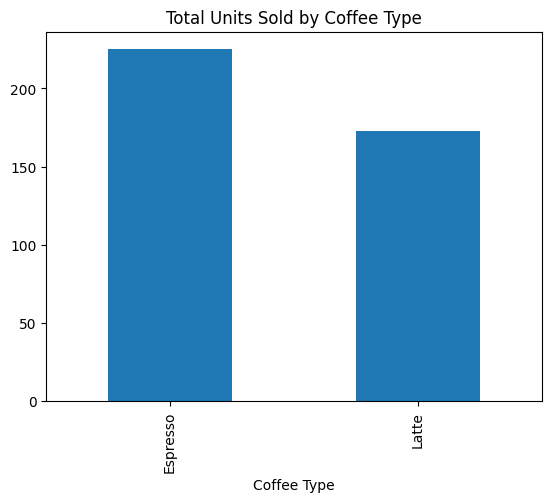

In [93]:
%matplotlib inline
cfe.groupby('Coffee Type')['Units Sold'].sum().plot(kind='bar', title='Total Units Sold by Coffee Type')

## 17. Summary

You've now covered:
- Series & DataFrame fundamentals
- Label vs. position based selection
- Filtering with booleans, strings, regex, and `.query()`
- Column creation, transformation, and datetime handling
- Custom row/column logic with `.apply()`
- Merging, concatenating, and cleaning missing data
- Aggregation, grouping, and pivoting
- Duplicates, replacing values, and cross-tabulation
- Window functions for time-series-style analysis
- Method chaining and performance-aware pandas usage

**Next steps:** try these same operations on a larger, messier dataset (e.g. from Kaggle) to
practice handling real-world quirks like inconsistent types, encoding issues, and larger-scale
performance tuning.
